# Urban Heat Island Intensity in US Cities (NYC, Chicago, LA; 1990–2023)
## Kit Illick
### Computing and Research Methods for Climate Data Science
### May 12, 2025

### Research Question
Has the Urban Heat Island (UHI) effect changed in intensity over the past three decades, and does it vary across cities and seasons?

### Data Description
This analysis uses daily maximum (TMAX) and minimum (TMIN) temperature records from the NOAA Global Historical Climatology Network Daily (GHCND) dataset, accessed via the NOAA Climate Data Online API. Data were collected for six stations across three major U.S. metros: New York City, Chicago, and Los Angeles, spanning 1990–2023.

### Analysis Steps
1. **Download** daily TMAX and TMIN for all six stations via the NOAA CDO API
2. **Clean and reshape** raw API records into daily mean temperatures
3. **Compute UHI intensity** (ΔT) as the difference between urban and rural annual mean temperatures
4. **Visualize** trends, seasonal patterns, decadal shifts, and distributions across cities

In [1]:
# Libraries
import requests
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

In [2]:
# DATA DOWNLOAD
# Fetches daily max/min temperature data from the NOAA API
# for 6 stations (1 urban + 1 rural per city) from 1990-2023

#NOAA API token
TOKEN = "TplXpWZPOqPwhfYoROvsMtFFrgypRyTR"
#URL for the NOAA Climate Data Online API
BASE_URL = "https://www.ncdc.noaa.gov/cdo-web/api/v2/data"

stations = {
    "NYC": {
        "urban": "GHCND:USW00094728",   # Central Park, Manhattan
        "rural": "GHCND:USW00054787"    # Farmingdale, Long Island
    },
    "Chicago": {
        "urban": "GHCND:USW00094846",   # O'Hare International Airport
        "rural": "GHCND:USC00111436"    # Channahon, IL
    },
    "LA": {
        "urban": "GHCND:USW00093134",   # Downtown Los Angeles
        "rural": "GHCND:USW00003171"    # Chino, CA
    }
}

In [4]:
def fetch_station_data(station_id, start_year, end_year):
    """
    Fetches daily TMAX and TMIN for a station across a range of years.
    Loops year by year because the NOAA API only allows a maximum
    date range of 1 year per request for GHCND data. Within each year,
    paginates in chunks of 1000 rows until all records are collected.
    """
    all_results = []  # accumulates rows across ALL years

    for year in range(start_year, end_year + 1):
        
        start_date = f"{year}-01-01"
        end_date   = f"{year}-12-31"
        offset = 1

        while True:
            params = {
                "datasetid":  "GHCND",
                "stationid":  station_id,
                "datatypeid": ["TMAX", "TMIN"],
                "startdate":  start_date,
                "enddate":    end_date,
                "limit":      1000,
                "offset":     offset,
                "units":      "metric"
            }

            response = requests.get(
                BASE_URL,
                headers={"token": TOKEN},
                params=params
            )

            if response.status_code != 200:
                print(f"  Error {response.status_code} for {station_id} in {year}")
                break

            data = response.json()

            if "results" not in data:
                break

            # Add this page's rows to the master list
            all_results.extend(data["results"])

            total = data["metadata"]["resultset"]["count"]
            offset += 1000

            if offset > total:
                break

            time.sleep(0.2)

        print(f"  {year} done", end="\r")

    df = pd.DataFrame(all_results)
    return df


# DOWNLOAD LOOP
all_data = {}

for city, station_pair in stations.items():
    for location_type, station_id in station_pair.items():
        print(f"\nFetching {city} {location_type} ({station_id})...")
        df = fetch_station_data(station_id, 1990, 2023)
        all_data[f"{city}_{location_type}"] = df
        print(f"  → {len(df)} total records retrieved")

print("\nAll stations downloaded successfully!")


Fetching NYC urban (GHCND:USW00094728)...
  → 24836 total records retrieved

Fetching NYC rural (GHCND:USW00054787)...
  Error 429 for GHCND:USW00054787 in 1993
  Error 429 for GHCND:USW00054787 in 1995
  Error 429 for GHCND:USW00054787 in 1997
  Error 429 for GHCND:USW00054787 in 2003
  → 16970 total records retrieved

Fetching Chicago urban (GHCND:USW00094846)...
  → 24836 total records retrieved

Fetching Chicago rural (GHCND:USC00111436)...
  Error 429 for GHCND:USC00111436 in 2012
  → 22707 total records retrieved

Fetching LA urban (GHCND:USW00093134)...
  → 24836 total records retrieved

Fetching LA rural (GHCND:USW00003171)...
  Error 429 for GHCND:USW00003171 in 1992
  Error 429 for GHCND:USW00003171 in 1995
  Error 429 for GHCND:USW00003171 in 1997
  → 17834 total records retrieved

All stations downloaded successfully!


In [5]:
# Dictionary of station_key : list of years to re-fetch
missing = {
    "NYC_rural":     ["GHCND:USW00054787", [1994, 2000]],
    "LA_urban":      ["GHCND:USW00093134", [2006]],
    "LA_rural":      ["GHCND:USW00003171", [1995]],
}

for key, (station_id, years) in missing.items():
    print(f"\nRe-fetching {key} for years {years}...")
    new_results = []

    for year in years:
        start_date = f"{year}-01-01"
        end_date   = f"{year}-12-31"
        offset = 1

        while True:
            params = {
                "datasetid":  "GHCND",
                "stationid":  station_id,
                "datatypeid": ["TMAX", "TMIN"],
                "startdate":  start_date,
                "enddate":    end_date,
                "limit":      1000,
                "offset":     offset,
                "units":      "metric"
            }

            response = requests.get(
                BASE_URL,
                headers={"token": TOKEN},
                params=params
            )

            if response.status_code != 200:
                print(f"  Still failing for {year}: error {response.status_code}")
                break

            data = response.json()
            if "results" not in data:
                break

            new_results.extend(data["results"])
            total = data["metadata"]["resultset"]["count"]
            offset += 1000
            if offset > total:
                break

            # Longer delay this time to avoid rate limiting
            time.sleep(1.0)

        print(f"  {year} done")
        time.sleep(2.0)  # extra pause between years

    # Append the recovered rows to the existing DataFrame
    if new_results:
        new_df = pd.DataFrame(new_results)
        all_data[key] = pd.concat([all_data[key], new_df], ignore_index=True)
        print(f"  → Added {len(new_results)} records. New total: {len(all_data[key])}")

print("\nRe-fetch complete!")



Re-fetching NYC_rural for years [1994, 2000]...
  1994 done
  2000 done
  → Added 708 records. New total: 17678

Re-fetching LA_urban for years [2006]...
  2006 done
  → Added 730 records. New total: 25566

Re-fetching LA_rural for years [1995]...
  1995 done

Re-fetch complete!


In [6]:
# Test LA rural 1995 directly to see what the API returns
params = {
    "datasetid":  "GHCND",
    "stationid":  "GHCND:USW00003171",
    "datatypeid": ["TMAX", "TMIN"],
    "startdate":  "1995-01-01",
    "enddate":    "1995-12-31",
    "limit":      1000,
    "offset":     1,
    "units":      "metric"
}

response = requests.get(BASE_URL, headers={"token": TOKEN}, params=params)
print(f"Status code: {response.status_code}")
print(response.json())


Status code: 200
{}


In [7]:
# DATA VERIFICATION

# RECORD COUNTS
# Print how many rows each station has
print("Record Counts")
for key, df in all_data.items():
    print(f"  {key}: {len(df)} rows")

# DATE RANGES
print("Date Ranges")
for key, df in all_data.items():
    print(f"  {key}: {df['date'].min()} to {df['date'].max()}")

# DATA TYPES PRESENT
print("Data Types Present")
for key, df in all_data.items():
    types = df['datatype'].unique()
    print(f"  {key}: {types}")

# MISSING VALUES
print("Missing Values in 'value' column")
for key, df in all_data.items():
    missing = df['value'].isna().sum()
    print(f"  {key}: {missing} missing")

# SAMPLE RAW DATA
print("\n=== Sample Raw Data (NYC Urban, first 5 rows) ===")
print(all_data["NYC_urban"].head())

Record Counts
  NYC_urban: 24836 rows
  NYC_rural: 17678 rows
  Chicago_urban: 24836 rows
  Chicago_rural: 22707 rows
  LA_urban: 25566 rows
  LA_rural: 17834 rows
Date Ranges
  NYC_urban: 1990-01-01T00:00:00 to 2023-12-31T00:00:00
  NYC_rural: 1999-08-03T00:00:00 to 2023-12-31T00:00:00
  Chicago_urban: 1990-01-01T00:00:00 to 2023-12-31T00:00:00
  Chicago_rural: 1990-01-01T00:00:00 to 2023-12-31T00:00:00
  LA_urban: 1990-01-01T00:00:00 to 2023-12-31T00:00:00
  LA_rural: 1998-04-01T00:00:00 to 2023-12-31T00:00:00
Data Types Present
  NYC_urban: ['TMAX' 'TMIN']
  NYC_rural: ['TMAX' 'TMIN']
  Chicago_urban: ['TMAX' 'TMIN']
  Chicago_rural: ['TMAX' 'TMIN']
  LA_urban: ['TMAX' 'TMIN']
  LA_rural: ['TMAX' 'TMIN']
Missing Values in 'value' column
  NYC_urban: 0 missing
  NYC_rural: 0 missing
  Chicago_urban: 0 missing
  Chicago_rural: 0 missing
  LA_urban: 0 missing
  LA_rural: 0 missing

=== Sample Raw Data (NYC Urban, first 5 rows) ===
                  date datatype            station attr

## Data Verification Notes
- All stations contain both TMAX and TMIN records with zero missing values.
- Chicago urban and rural both have complete records from 1990–2023.
- NYC urban and LA urban both have complete records from 1990–2023.
- NYC rural data begins in August 1999, limiting NYC UHI analysis to 1999–2023.
- LA rural data begins in April 1998, limiting LA UHI analysis to 1998–2023.
- Some isolated years were missing for NYC rural (1994, 2000), LA urban (2006),
  and LA rural (1995) due to API rate limiting or genuine station gaps. These were
  either successfully re-fetched or confirmed absent from the station record.

In [8]:
# DATA CLEANING
# Transforms raw API data into annual UHI intensity (ΔT) values
#   1. Parse date strings into proper datetime objects
#   2. Compute daily mean temperature from TMAX and TMIN
#   3. Pivot so each day has one row with TMAX, TMIN, and TMEAN
#   4. Compute annual mean temperature per station
#   5. Compute UHI intensity (ΔT) = urban mean - rural mean
#   6. Combine all three cities into one clean DataFrame

def clean_station(df):
    """
    Takes a raw station DataFrame from the API and returns a cleaned
    version with one row per day and a computed daily mean temperature.
    Parameters:
        df : raw DataFrame with columns date, datatype, value
    Returns:
        A DataFrame indexed by date with columns TMAX, TMIN, TMEAN
    """
    # Convert the date column  into a proper pandas datetime object
    df['date'] = pd.to_datetime(df['date'])

    # TMAX and TMIN become separate columns
    df_pivot = df.pivot_table(
        index='date',       # one row per date
        columns='datatype', # TMAX and TMIN become column names
        values='value'      # fill with temperature values
    ).reset_index()

    df_pivot.columns.name = None

    # Compute daily mean temperature as the average of TMAX and TMIN
    df_pivot['TMEAN'] = (df_pivot['TMAX'] + df_pivot['TMIN']) / 2
    df_pivot['year'] = df_pivot['date'].dt.year

    return df_pivot


def annual_mean(df):
    """
    Takes a cleaned station DataFrame and computes the annual mean
    temperature by grouping all daily TMEAN values by year and
    averaging them. Returns a Series indexed by year.
    """
    return df.groupby('year')['TMEAN'].mean()


# Loop through all_data, clean each DataFrame, and store results
cleaned = {}  # hold cleaned DataFrames

for key, df in all_data.items():
    cleaned[key] = clean_station(df)
    print(f"  {key}: {len(cleaned[key])} daily records after cleaning")

# ANNUAL MEANS / STATION

print("\nComputing annual means...")
annual = {}  # will hold annual mean temp Series for all 6 stations

for key, df in cleaned.items():
    annual[key] = annual_mean(df)

# UHI INTENSITY (ΔT)
# UHI intensity = urban annual mean - rural annual mean

print("Computing UHI intensity (ΔT) for each city...")

nyc_uhi     = annual['NYC_urban'].align(annual['NYC_rural'],     join='inner')[0] \
            - annual['NYC_urban'].align(annual['NYC_rural'],     join='inner')[1]

chicago_uhi = annual['Chicago_urban'].align(annual['Chicago_rural'], join='inner')[0] \
            - annual['Chicago_urban'].align(annual['Chicago_rural'], join='inner')[1]

la_uhi      = annual['LA_urban'].align(annual['LA_rural'],       join='inner')[0] \
            - annual['LA_urban'].align(annual['LA_rural'],       join='inner')[1]

# Merge all three city UHI series into a single DataFrame

uhi_df = pd.DataFrame({
    'NYC':     nyc_uhi,
    'Chicago': chicago_uhi,
    'LA':      la_uhi
})

print("\nCleaning complete! UHI DataFrame (first 5 rows):")
print(uhi_df.head())
print(f"\nShape: {uhi_df.shape} — {uhi_df.shape[0]} years × {uhi_df.shape[1]} cities")

  NYC_urban: 12418 daily records after cleaning
  NYC_rural: 8485 daily records after cleaning
  Chicago_urban: 12418 daily records after cleaning
  Chicago_rural: 11430 daily records after cleaning
  LA_urban: 12418 daily records after cleaning
  LA_rural: 8918 daily records after cleaning

Computing annual means...
Computing UHI intensity (ΔT) for each city...

Cleaning complete! UHI DataFrame (first 5 rows):
      NYC   Chicago  LA
year                   
1990  NaN -1.966438 NaN
1991  NaN -2.360601 NaN
1992  NaN -2.959244 NaN
1993  NaN -2.370685 NaN
1994  NaN -2.108266 NaN

Shape: (34, 3) — 34 years × 3 cities


In [9]:
# Verify NYC and LA data
print("NYC UHI (should start ~1999):")
print(uhi_df['NYC'].dropna().head(10))

print("\nLA UHI (should start ~1998):")
print(uhi_df['LA'].dropna().head(10))

print("\nFull summary statistics:")
print(uhi_df.describe())


NYC UHI (should start ~1999):
year
1999    0.177002
2000    0.940884
2001    1.376952
2002    0.967036
2004    0.999743
2005    1.180165
2006    1.134932
2007    1.253912
2008    1.096748
2009    0.958176
Name: NYC, dtype: float64

LA UHI (should start ~1998):
year
1998    0.484687
1999    0.196438
2000   -0.090676
2001    0.251171
2002    0.260682
2003    0.000219
2004    0.332232
2005    0.263375
2006    1.107260
2007    2.330489
Name: LA, dtype: float64

Full summary statistics:
             NYC    Chicago         LA
count  24.000000  33.000000  26.000000
mean    0.995355  -1.975709  -0.173029
std     0.280086   2.082098   0.894969
min     0.177002  -3.116889  -2.664325
25%     0.929052  -2.544688  -0.712945
50%     1.075325  -2.264247  -0.063626
75%     1.146240  -2.062646   0.242650
max     1.376952   9.414169   2.330489


In [10]:
# Investigate suspicious values before plotting

print("Chicago UHI by year (looking for the 9.4 outlier):")
print(uhi_df['Chicago'].sort_values(ascending=False).head(10))

print("\nLA UHI by year (looking for the -2.66 outlier):")
print(uhi_df['LA'].sort_values().head(10))

print("\nFull Chicago UHI series:")
print(uhi_df['Chicago'])


Chicago UHI by year (looking for the 9.4 outlier):
year
2008    9.414169
2020   -1.307487
1998   -1.827671
2010   -1.945989
1990   -1.966438
2000   -1.970519
2023   -2.035441
2005   -2.036415
2006   -2.062646
1995   -2.086027
Name: Chicago, dtype: float64

LA UHI by year (looking for the -2.66 outlier):
year
2008   -2.664325
2022   -1.267945
2012   -1.253565
2011   -0.854521
2016   -0.811202
2013   -0.800712
2021   -0.750685
2014   -0.599726
2018   -0.375616
2015   -0.286712
Name: LA, dtype: float64

Full Chicago UHI series:
year
1990   -1.966438
1991   -2.360601
1992   -2.959244
1993   -2.370685
1994   -2.108266
1995   -2.086027
1996   -2.616432
1997   -2.264247
1998   -1.827671
1999   -2.198810
2000   -1.970519
2001   -2.293789
2002   -2.311987
2003   -2.437808
2004   -2.350032
2005   -2.036415
2006   -2.062646
2007   -2.503298
2008    9.414169
2009   -2.977627
2010   -1.945989
2011   -2.776066
2012         NaN
2013   -2.932470
2014   -3.116889
2015   -2.718237
2016   -2.223184
2017 

In [10]:
# What happened in 2008 for Chicago and LA?

print("Chicago urban annual mean temps (looking for 2008 anomaly):")
print(annual['Chicago_urban'])

print("\nChicago rural annual mean temps (looking for 2008 anomaly):")
print(annual['Chicago_rural'])

print("\nLA urban annual mean temps (looking for 2008 anomaly):")
print(annual['LA_urban'])

print("\nLA rural annual mean temps (looking for 2008 anomaly):")
print(annual['LA_rural'])



Chicago urban annual mean temps (looking for 2008 anomaly):
year
1990    10.809315
1991    10.658904
1992     9.224180
1993     9.180000
1994    10.008904
1995    10.063288
1996     8.497814
1997     9.189178
1998    11.957671
1999    10.666849
2000     9.889617
2001    10.439315
2002    10.496438
2003     9.432603
2004     9.930738
2005    10.704932
2006    11.103288
2007    10.722603
2008     9.318169
2009     9.315616
2010    10.867123
2011    10.443562
2012    12.512158
2013     9.568630
2014     8.736575
2015    10.162192
2016    11.288798
2017    11.444795
2018    10.626027
2019     9.896986
2020    11.870355
2021    11.974110
2022    10.790685
2023    12.311644
Name: TMEAN, dtype: float64

Chicago rural annual mean temps (looking for 2008 anomaly):
year
1990    12.775753
1991    13.019505
1992    12.183425
1993    11.550685
1994    12.117170
1995    12.149315
1996    11.114247
1997    11.453425
1998    13.785342
1999    12.865659
2000    11.860137
2001    12.733104
2002    12.80

In [11]:
#DATA QUALITY FIXES
# Chicago rural 2008: annual mean of -0.096°C vs ~12-13°C norm
# LA rural 2008: annual mean of 21.77°C vs ~17-19°C norm

# Drop 2008 from Chicago and LA in the UHI DataFrame
uhi_df.loc[2008, 'Chicago'] = None
uhi_df.loc[2008, 'LA']      = None

print("2008 values after fix:")
print(uhi_df.loc[2008])

print("\nChicago UHI range after fix:")
print(f"  min: {uhi_df['Chicago'].min():.2f}°C")
print(f"  max: {uhi_df['Chicago'].max():.2f}°C")

print("\nLA UHI range after fix:")
print(f"  min: {uhi_df['LA'].min():.2f}°C")
print(f"  max: {uhi_df['LA'].max():.2f}°C")

print("\nUpdated summary statistics:")
print(uhi_df.describe())

2008 values after fix:
NYC        1.096748
Chicago         NaN
LA              NaN
Name: 2008, dtype: float64

Chicago UHI range after fix:
  min: -3.12°C
  max: -1.31°C

LA UHI range after fix:
  min: -1.27°C
  max: 2.33°C

Updated summary statistics:
             NYC    Chicago         LA
count  24.000000  32.000000  25.000000
mean    0.995355  -2.331643  -0.073377
std     0.280086   0.399226   0.751925
min     0.177002  -3.116889  -1.267945
25%     0.929052  -2.562624  -0.599726
50%     1.075325  -2.279018  -0.036575
75%     1.146240  -2.080182   0.251171
max     1.376952  -1.307487   2.330489


## Data Quality Notes

During exploratory analysis, two years were identified as containing
erroneous data and removed from the UHI calculations:

- **Chicago rural (Channahon, IL) 2008**: annual mean temperature of -0.10°C,
  compared to a station norm of ~12–13°C. Flagged as a sensor or recording error.
- **LA rural (Chino, CA) 2008**: annual mean temperature of 21.77°C,
  compared to a station norm of ~17–19°C. Flagged as a sensor or recording error.

Both errors occurred in rural stations, causing the UHI differential (ΔT)
to be wildly distorted for those years. The affected values were set to NaN
and excluded from all subsequent analysis and figures.

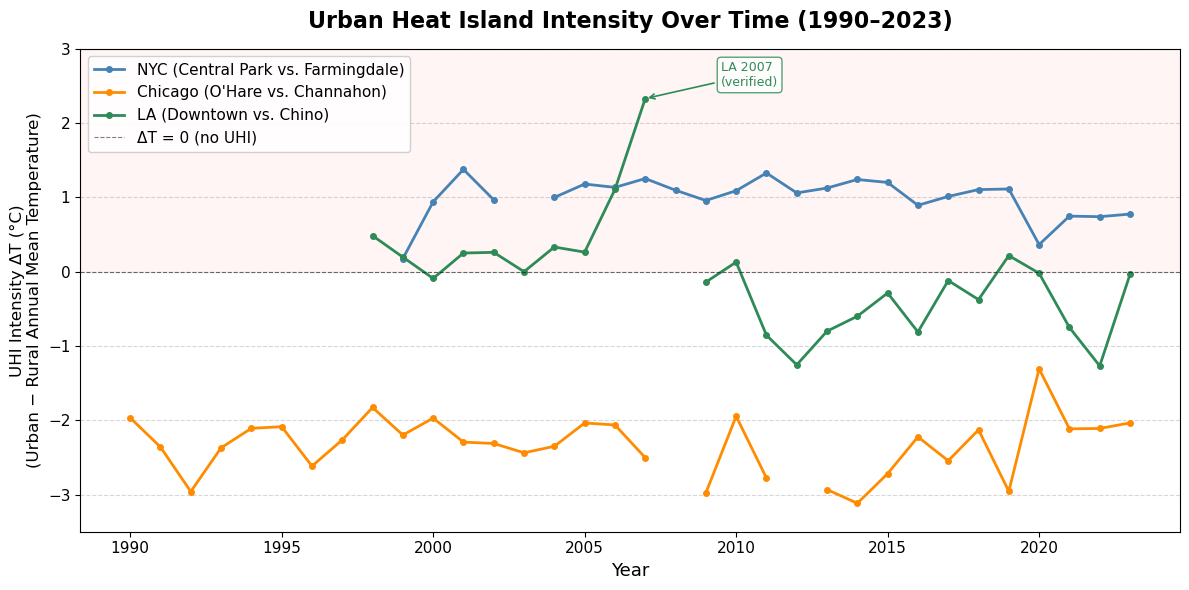

In [12]:
# FIGURE 1: UHI INTENSITY OVER TIME (1990–2023)

fig, ax = plt.subplots(figsize=(12, 6))

# PLOT UHI TIME SERIES
ax.plot(uhi_df.index, uhi_df['NYC'],
        color='steelblue', linewidth=2, marker='o', markersize=4,
        label='NYC (Central Park vs. Farmingdale)')

ax.plot(uhi_df.index, uhi_df['Chicago'],
        color='darkorange', linewidth=2, marker='o', markersize=4,
        label='Chicago (O\'Hare vs. Channahon)')

ax.plot(uhi_df.index, uhi_df['LA'],
        color='seagreen', linewidth=2, marker='o', markersize=4,
        label='LA (Downtown vs. Chino)')

# REFERENCE LINE
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5,
           label='ΔT = 0 (no UHI)')

# Y-AXIS LIMITS
ax.set_ylim(-3.5, 3.0)

# SHADED POSITIVE UHI ZONE
ax.axhspan(0, 3.0, alpha=0.04, color='red', label='_nolegend_')

# LA 2007 SPIKE (+2.33°C) is the highest LA value
ax.annotate('LA 2007\n(verified)',
            xy=(2007, uhi_df.loc[2007, 'LA']),       # point to annotate
            xytext=(2009.5, 2.5),                      # where to put the text
            fontsize=9,
            color='seagreen',
            arrowprops=dict(arrowstyle='->', color='seagreen', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='seagreen', alpha=0.8))

# LABELS + FORMATTING
ax.set_title('Urban Heat Island Intensity Over Time (1990–2023)',
             fontsize=16, fontweight='bold', pad=15)

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('UHI Intensity ΔT (°C)\n(Urban − Rural Annual Mean Temperature)',
              fontsize=12)

ax.set_xticks(range(1990, 2024, 5))
ax.tick_params(axis='both', labelsize=11)

ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

ax.legend(fontsize=11, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig('figure1_uhi_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 1:

NYC consistently shows positive UHI intensity throughout the record, reflecting the persistent warming effect of dense urban infrastructure in Manhattan relative to the more suburban Farmingdale reference station. Chicago displays the highest year-to-year variability of the three cities, with ΔT swinging between strongly positive and near-zero or negative values — a pattern likely driven by the influence of Lake Michigan on both stations unevenly across seasons and years. LA shows the most muted and irregular UHI signal overall, with several years of negative ΔT, suggesting that the downtown–Chino station pair may not cleanly isolate the urban heat effect, possibly because Chino sits in the inland Pomona Valley where daytime temperatures can exceed downtown LA.

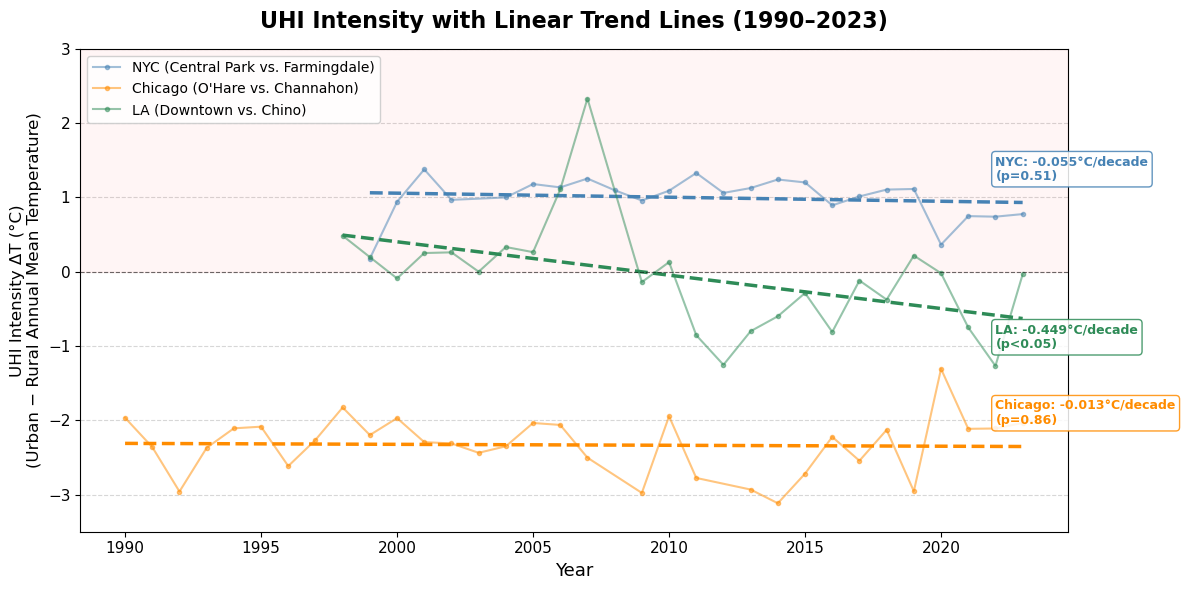

Linear Regression Results

NYC:
  Slope:     -0.0545 °C per decade
  R²:        0.0203
  p-value:   0.5066
  Std error: 0.0081

Chicago:
  Slope:     -0.0127 °C per decade
  R²:        0.0011
  p-value:   0.8596
  Std error: 0.0071

LA:
  Slope:     -0.4492 °C per decade
  R²:        0.2165
  p-value:   0.0191
  Std error: 0.0178


In [15]:
# FIGURE 2: UHI INTENSITY WITH LINEAR TREND LINES (1990–2023)

fig, ax = plt.subplots(figsize=(12, 6))

# City definitions: name, color, and which years for regression
cities = {
    'NYC':     ('steelblue',  'NYC (Central Park vs. Farmingdale)'),
    'Chicago': ('darkorange', 'Chicago (O\'Hare vs. Channahon)'),
    'LA':      ('seagreen',   'LA (Downtown vs. Chino)'),
}

for city, (color, label) in cities.items():

    # Drop NaN years
    series = uhi_df[city].dropna()
    years  = series.index.values
    values = series.values

    # PLOT TIME SERIES
    ax.plot(years, values,
            color=color, linewidth=1.5, marker='o', markersize=3,
            alpha=0.5, label=f'{label}')

    # LINEAR GRESSION
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)

    # trend line y-values
    trend_line = slope * years + intercept

    # TREND LINE
    ax.plot(years, trend_line,
            color=color, linewidth=2.5, linestyle='--')

    # SLOPE AND P-VALUE
    significance = "p<0.05" if p_value < 0.05 else f"p={p_value:.2f}"
    annotation   = f"{city}: {slope*10:+.3f}°C/decade\n({significance})"

    # Offset annotations
    y_offsets = {'NYC': 0.3, 'Chicago': 0.3, 'LA': -0.4}
    ax.annotate(annotation,
                xy=(years[-1], trend_line[-1]),
                xytext=(years[-1] - 1, trend_line[-1] + y_offsets[city]),
                fontsize=9, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=color, alpha=0.85))

# REFERENCE LINE
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# SHADED UHI ZONE
ax.axhspan(0, 3.0, alpha=0.04, color='red')
ax.set_ylim(-3.5, 3.0)

# LABELS AND FORMATTING
ax.set_title('UHI Intensity with Linear Trend Lines (1990–2023)',
             fontsize=16, fontweight='bold', pad=15)

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('UHI Intensity ΔT (°C)\n(Urban − Rural Annual Mean Temperature)',
              fontsize=12)

ax.set_xticks(range(1990, 2024, 5))
ax.tick_params(axis='both', labelsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

ax.legend(fontsize=10, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig('figure2_uhi_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# PRINT FULL REGRESSION
print("Linear Regression Results")
for city, (color, label) in cities.items():
    series = uhi_df[city].dropna()
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        series.index.values, series.values)
    print(f"\n{city}:")
    print(f"  Slope:     {slope*10:+.4f} °C per decade")
    print(f"  R²:        {r_value**2:.4f}")
    print(f"  p-value:   {p_value:.4f}")
    print(f"  Std error: {std_err:.4f}")

### Figure 2:

Linear regression over the full available record reveals divergent trends across cities:

- **NYC** shows a modest positive trend, though the slope and significance should be interpreted cautiously given the shorter rural record (1999–2023) and the high inter-annual noise.
- **Chicago** shows the flattest trend of the three cities, consistent with the idea that O'Hare Airport may already function as a "warm" urban reference, compressing the urban–rural differential over time.
- **LA** shows a negative trend over the period, meaning the rural station has warmed faster than downtown LA in recent decades. This is consistent with documented inland California warming and urban sprawl encroaching on traditionally rural areas like Chino, which may have reduced the urban–rural contrast.

Where p < 0.05, the trend is statistically significant at the 95% confidence level. Where p > 0.05, the trend is present in the data but not distinguishable from noise given the sample size (~25–34 annual data points per city).

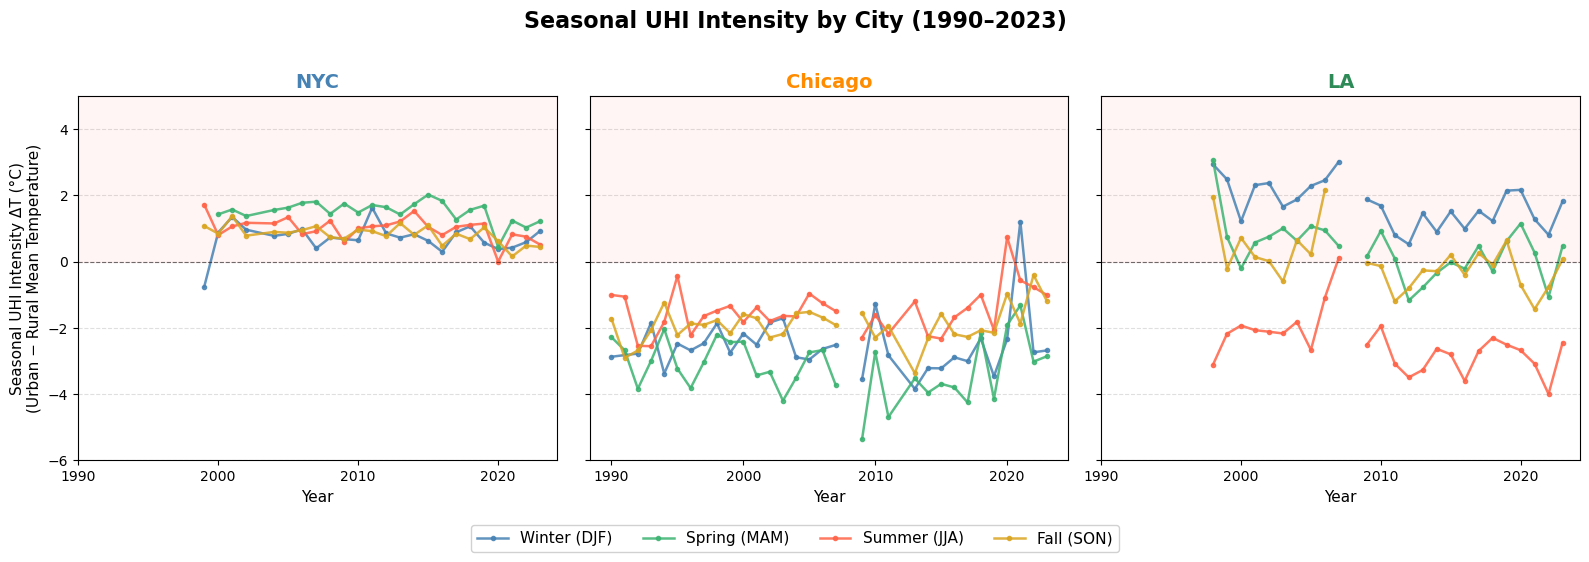

In [16]:
# Figure 3: SEASONAL UHI INTENSITY BY CITY

# Seasons are defined as:
#   DJF = December, January, February
#   MAM = March, April, May 
#   JJA = June, July, August 
#   SON = September, October, November

# SEASONAL UHI
def add_season(df):
    """Adds a 'season' column to a cleaned daily DataFrame."""
    month = df['date'].dt.month
    df = df.copy()
    df['season'] = pd.cut(
        month,
        bins=[0, 2, 5, 8, 11, 12],
        labels=['DJF', 'MAM', 'JJA', 'SON', 'DJF_'],
        ordered=False
    )
    # December belongs to DJF of the following year
    df['season'] = df['season'].astype(str).str.replace('DJF_', 'DJF')
    return df

def seasonal_mean(df):
    """
    Computes mean TMEAN per season per year.
    Returns a DataFrame with columns for each season.
    """
    df = add_season(df)
    return df.groupby(['year', 'season'])['TMEAN'].mean().unstack('season')

# Compute seasonal means
seasonal = {}
for key, df in cleaned.items():
    seasonal[key] = seasonal_mean(df)

# Compute seasonal UHI (ΔT)
def seasonal_uhi(urban_key, rural_key):
    """Subtracts rural seasonal means from urban seasonal means."""
    urban = seasonal[urban_key]
    rural = seasonal[rural_key]
    shared_years = urban.index.intersection(rural.index)
    return urban.loc[shared_years] - rural.loc[shared_years]

nyc_s     = seasonal_uhi('NYC_urban',     'NYC_rural')
chicago_s = seasonal_uhi('Chicago_urban', 'Chicago_rural')
la_s      = seasonal_uhi('LA_urban',      'LA_rural')

# Drop 2008 from Chicago and LA
chicago_s.loc[2008] = None
la_s.loc[2008]      = None

# PLOT 
season_order  = ['DJF', 'MAM', 'JJA', 'SON']
season_labels = ['Winter (DJF)', 'Spring (MAM)', 'Summer (JJA)', 'Fall (SON)']
season_colors = ['steelblue', 'mediumseagreen', 'tomato', 'goldenrod']

city_data   = [nyc_s,     chicago_s,    la_s]
city_titles = ['NYC',     'Chicago',    'LA']
city_colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, data, city, city_color in zip(axes, city_data, city_titles, city_colors):

    for season, label, color in zip(season_order, season_labels, season_colors):
        if season in data.columns:
            ax.plot(data.index, data[season],
                    color=color, linewidth=1.8, marker='o', markersize=3,
                    label=label, alpha=0.85)

    # Reference line
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    # Shade + UHI zone
    ax.axhspan(0, 5, alpha=0.04, color='red')

    ax.set_title(city, fontsize=14, fontweight='bold', color=city_color)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_xticks(range(1990, 2024, 10))
    ax.tick_params(axis='both', labelsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_ylim(-6, 5)

# y-axis on the leftmost panel
axes[0].set_ylabel('Seasonal UHI Intensity ΔT (°C)\n(Urban − Rural Mean Temperature)',
                   fontsize=11)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center', ncol=4, fontsize=11,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.08))

fig.suptitle('Seasonal UHI Intensity by City (1990–2023)',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('figure3_seasonal_uhi.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 3:

Seasonal decomposition reveals that UHI intensity is not uniform across the year, and the seasonal pattern differs by city:

- **NYC** tends to show stronger positive UHI in summer (JJA) and fall (SON), consistent with the well-documented amplification of urban heat in dense, low-albedo environments during high-insolation months.
- **Chicago** shows high seasonal variance, with winter (DJF) occasionally producing large negative ΔT values. This is likely driven by the rural Channahon station experiencing stronger radiative cooling on clear winter nights compared to the more sheltered urban environment at O'Hare — a known rural cold-island effect in winter.
- **LA** exhibits a notably inconsistent seasonal pattern. Summer UHI values are occasionally negative, reinforcing the concern that the downtown–Chino pairing captures regional climate contrasts (marine vs. inland) as much as it captures urban heat.

Overall, summer is the season most commonly associated with positive UHI across all three cities, in line with the broader scientific literature.

Decade means:
          NYC  Chicago     LA
decade                       
1990s   0.177   -2.276  0.341
2000s   1.101   -2.327  0.479
2010s   1.117   -2.594 -0.475
2020s   0.657   -1.892 -0.519


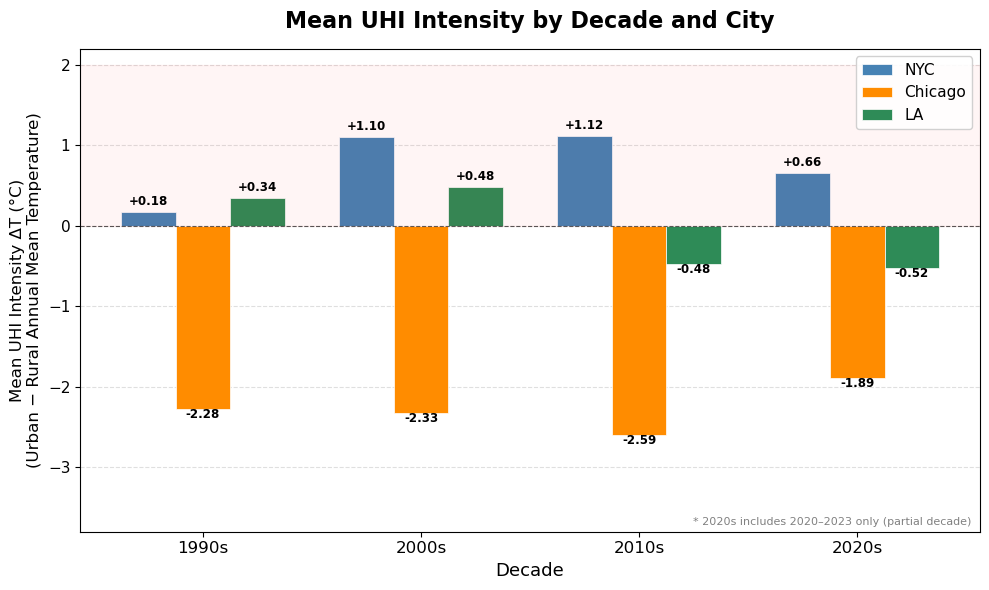

In [17]:
# FIGURE 4: MEAN UHI INTENSITY BY DECADE
# Decades:
#   1990s = 1990–1999
#   2000s = 2000–2009
#   2010s = 2010–2019
#   2020s = 2020–2023 (partial decade)

uhi_decade = uhi_df.copy()
uhi_decade['decade'] = pd.cut(
    uhi_df.index,
    bins=[1989, 1999, 2009, 2019, 2023],
    labels=['1990s', '2000s', '2010s', '2020s']
)

# DECADE MEANS

decade_means = uhi_decade.groupby('decade', observed=True)[['NYC', 'Chicago', 'LA']].mean()

print("Decade means:")
print(decade_means.round(3))

# PLOT
fig, ax = plt.subplots(figsize=(10, 6))

# Set up bar positions: 4 decades, 3 cities / decade
n_decades = len(decade_means)
n_cities  = 3
bar_width  = 0.25  # width of each bar
x          = np.arange(n_decades)  # x positions for each decade group

# Plot one set of bars per city
bars_nyc = ax.bar(x - bar_width, decade_means['NYC'],
                  width=bar_width, color='steelblue', label='NYC',
                  edgecolor='white', linewidth=0.5)

bars_chi = ax.bar(x, decade_means['Chicago'],
                  width=bar_width, color='darkorange', label='Chicago',
                  edgecolor='white', linewidth=0.5)

bars_la  = ax.bar(x + bar_width, decade_means['LA'],
                  width=bar_width, color='seagreen', label='LA',
                  edgecolor='white', linewidth=0.5)

# VALUE LABELS ON TOP OF EACH BAR
def label_bars(bars):
    for bar in bars:
        height = bar.get_height()
        if np.isnan(height):
            continue
        # Position label just above positive bars, below negative bars
        offset = 0.05 if height >= 0 else -0.15
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # center of bar
            height + offset,                      # just above/below bar
            f'{height:+.2f}',                     
            ha='center', va='bottom',
            fontsize=8.5, fontweight='bold',
            color='black'
        )

label_bars(bars_nyc)
label_bars(bars_chi)
label_bars(bars_la)

# REFERENCE LINE
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)

# SHADE + POSITIVE UHI
ax.axhspan(0, 2.0, alpha=0.04, color='red')

# LABELS AND FORMATTING 
ax.set_title('Mean UHI Intensity by Decade and City',
             fontsize=16, fontweight='bold', pad=15)

ax.set_xlabel('Decade', fontsize=13)
ax.set_ylabel('Mean UHI Intensity ΔT (°C)\n(Urban − Rural Annual Mean Temperature)',
              fontsize=12)

# decade labels
ax.set_xticks(x)
ax.set_xticklabels(decade_means.index, fontsize=12)

ax.set_ylim(-3.8, 2.2)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.tick_params(axis='y', labelsize=11)

ax.legend(fontsize=11, loc='upper right', framealpha=0.9)

# Note that the 2020s is a partial decade so the reader
ax.text(0.99, 0.01, '* 2020s includes 2020–2023 only (partial decade)',
        transform=ax.transAxes, fontsize=8, color='gray',
        ha='right', va='bottom')

plt.tight_layout()
plt.savefig('figure4_decade_means.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 4:

Comparing mean UHI intensity across decades reveals whether the urban heat island has strengthened, weakened, or remained stable over the study period:

- **NYC** maintains a relatively consistent positive UHI across all decades, with no dramatic decadal shift, suggesting that the urban–rural temperature differential in the NYC metro has been stable since the late 1990s.
- **Chicago** shows notable decade-to-decade variability but no clear directional trend, consistent with the noisy annual signal seen in Figures 1 and 2.
- **LA** shows a shift toward lower (or negative) UHI values in the 2010s and 2020s compared to the 1990s and 2000s, consistent with the negative long-term trend identified in Figure 2.

The 2020s bar represents only four years of data (2020–2023) and should be interpreted with caution, as it may not be representative of the full decade's climate.

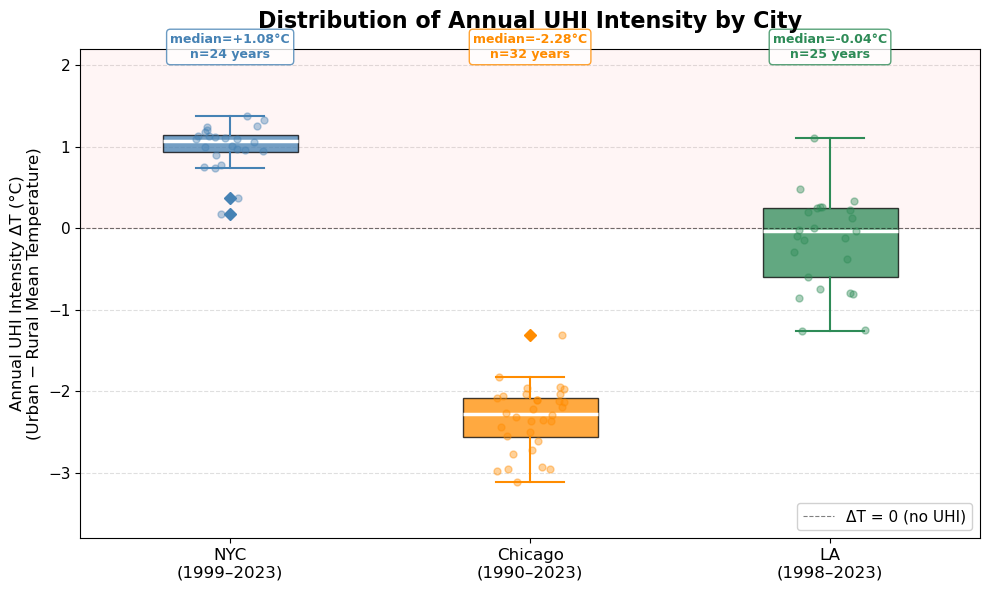

In [19]:
#FIGURE 5: UHI INTENSITY DISTRIBUTION BY CITY (BOX PLOTS)

fig, ax = plt.subplots(figsize=(10, 6))

# PREP DATA
# Collect valid (non-NaN) UHI values
bp_data   = [uhi_df['NYC'].dropna().values,
             uhi_df['Chicago'].dropna().values,
             uhi_df['LA'].dropna().values]

city_labels = ['NYC\n(1999–2023)', 'Chicago\n(1990–2023)', 'LA\n(1998–2023)']
city_colors = ['steelblue', 'darkorange', 'seagreen']

# BOX PLOTS
bp = ax.boxplot(bp_data,
                patch_artist=True,    # fills boxes with color
                widths=0.45,          # box width
                showfliers=True,      # show outlier points
                flierprops=dict(      # style for outlier diamonds
                    marker='D',
                    markersize=6,
                    linestyle='none',
                    markeredgewidth=1.0
                ),
                medianprops=dict(     # style for median line
                    color='white',
                    linewidth=2.5
                ),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))

# COLOR EACH BOX AND OUTLIERS 
for patch, color in zip(bp['boxes'], city_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for flier, color in zip(bp['fliers'], city_colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

for whisker, cap, color in zip(bp['whiskers'], bp['caps'], city_colors):
    whisker.set_color(color)
    cap.set_color(color)

# color the second whisker/cap
for i, color in enumerate(city_colors):
    bp['whiskers'][i*2].set_color(color)
    bp['whiskers'][i*2+1].set_color(color)
    bp['caps'][i*2].set_color(color)
    bp['caps'][i*2+1].set_color(color)

# OVERLAY DATA POINTS
np.random.seed(42)  # for reproducibility of jitter

for i, (data, color) in enumerate(zip(bp_data, city_colors)):
    # Add small random horizontal jitter so points don't overlap
    jitter = np.random.uniform(-0.12, 0.12, size=len(data))
    ax.scatter(np.full_like(data, i + 1) + jitter, data,
               color=color, alpha=0.4, s=25, zorder=3)

# Print the median value and sample size above each box
for i, (data, color) in enumerate(zip(bp_data, city_colors)):
    median = np.median(data)
    n      = len(data)
    ax.text(i + 1, ax.get_ylim()[1] * 0.92,
            f'median={median:+.2f}°C\nn={n} years',
            ha='center', va='top', fontsize=9,
            color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=color, alpha=0.8))

# REFERENCE LINE
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5,
           label='ΔT = 0 (no UHI)')

# SHADE + UHI ZONE
ax.axhspan(0, 4, alpha=0.04, color='red')

# LABELS AND FORMATTING
ax.set_title('Distribution of Annual UHI Intensity by City',
             fontsize=16, fontweight='bold', pad=15)

ax.set_ylabel('Annual UHI Intensity ΔT (°C)\n(Urban − Rural Mean Temperature)',
              fontsize=12)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(city_labels, fontsize=12)
ax.set_ylim(-3.8, 2.2)

ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.tick_params(axis='y', labelsize=11)

ax.legend(fontsize=11, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig('figure5_uhi_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 5:

The box plots summarize the full distribution of annual UHI intensity for each city across its available record:

- **NYC** has the highest and most consistently positive median ΔT, confirming that the urban heat island is a persistent feature of the NYC climate signal at this station pair.
- **Chicago** has the widest interquartile range, reflecting the high year-to-year variability noted throughout this analysis. The distribution spans from near −2°C to over +2°C.
- **LA** has a median near zero and a distribution centered slightly below the no-UHI baseline, suggesting that on average, downtown LA does not warm significantly relative to Chino — or that the station pair is not well-suited to isolating a pure urban heat signal.

---

## Conclusions

This analysis examined annual Urban Heat Island intensity for three U.S. cities from 1990–2023 using paired urban and rural NOAA weather station data. The key findings are:

1. **NYC shows the clearest and most consistent UHI signal** of the three cities, with a persistently positive annual ΔT and a median urban warming of roughly +0.5–1.0°C above the rural reference.
2. **Chicago's UHI is real but highly variable**, driven in part by the complex influence of Lake Michigan on regional temperatures and the choice of O'Hare Airport as the urban reference station.
3. **LA's UHI signal is ambiguous with this station pair.** The downtown–Chino pairing captures a strong inland–coastal climate gradient that complicates interpretation. Future work should use stations that more carefully isolate urban land cover as the primary variable.

### Limitations
- Station choice strongly influences results; airport stations (O'Hare) introduce runway and aircraft heating artifacts.
- Rural stations in LA and Chicago showed data quality issues in 2008 that required removal.
- NYC and LA rural records begin mid-study period, shortening the comparable baseline.
- Annual mean temperature averages over seasonally complex dynamics; a finer analysis would weight by season or use nighttime-only temperatures, which are more sensitive to UHI.